In [12]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os
from dotenv import load_dotenv

load_dotenv()

def get_chat():
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        huggingfacehub_api_token=os.environ["HUGGINGFACEHUB_API_TOKEN"],
        temperature=0,
    )
    return ChatHuggingFace(llm=llm)

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [14]:
class batsman_state(TypedDict):
    runs: int
    balls: int
    number_of_fours: int
    number_of_sixes: int        
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    performance_summary: str
    

In [15]:
def calculate_strike_rate(state: batsman_state) :
    strike = (state['runs'] / state['balls']) * 100
    return {'strike_rate': strike}

def calculate_balls_per_boundary(state: batsman_state) :
    total_boundaries = state['number_of_fours'] + state['number_of_sixes']
    balls_per_boundary = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {'balls_per_boundary': balls_per_boundary}

def calculate_boundary_percentage(state: batsman_state) :
    total_boundaries = state['number_of_fours'] + state['number_of_sixes']
    boundary_percentage = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'boundary_percentage': boundary_percentage}

def summarize_performance(state: batsman_state) -> batsman_state:
    summary = f"The batsman scored {state['runs']} runs off {state['balls']} balls with a strike rate of {state['strike_rate']:.2f}. "
    summary += f"He hit {state['number_of_fours']} fours and {state['number_of_sixes']} sixes, with a boundary percentage of {state['boundary_percentage']:.2f}%."
    state['performance_summary'] = summary
    return state

In [16]:
graph = StateGraph(batsman_state)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('summarize_performance', summarize_performance)


graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage')


graph.add_edge('calculate_strike_rate', 'summarize_performance')
graph.add_edge('calculate_balls_per_boundary', 'summarize_performance')
graph.add_edge('calculate_boundary_percentage', 'summarize_performance')

graph.add_edge('summarize_performance', END)

workflow = graph.compile()

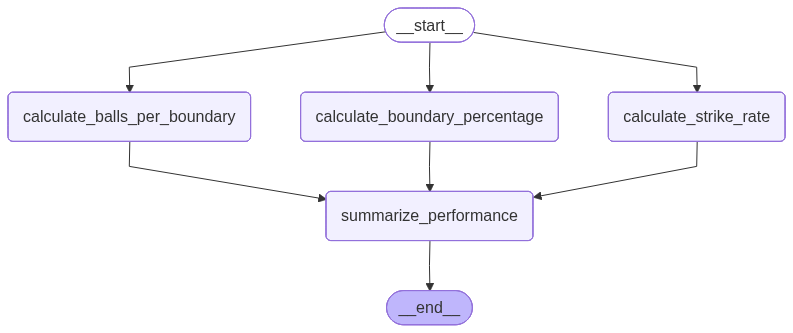

In [7]:
workflow

In [17]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "number_of_fours": 6,
    "number_of_sixes": 4
}
final_state = workflow.invoke(initial_state)
print(final_state["performance_summary"])

The batsman scored 100 runs off 50 balls with a strike rate of 200.00. He hit 6 fours and 4 sixes, with a boundary percentage of 20.00%.
